# **Zara Sales Analysis**

Exploring Customer Purchase Patterns and Product Performance


Here is all the data you need:
"zara.csv"

In [1]:
## Importing packages for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

## Loading the data

In [2]:
#load the data
df = pd.read_csv('zara.csv')
df.head()

,Product ID;Product Position;Promotion;Product Category;Seasonal;Sales Volume;brand;url;sku;name;description;price;currency;scraped_at;terms;section
0,185102;Aisle;No;Clothing;No;2823;Zara;https://...
1,188771;Aisle;No;Clothing;No;654;Zara;https://w...
2,180176;End-cap;Yes;Clothing;Yes;2220;Zara;http...
3,112917;Aisle;Yes;Clothing;Yes;1568;Zara;https:...
4,192936;End-cap;No;Clothing;Yes;2942;Zara;https...


In [3]:
# data is loaded correctly but but the single column contains all the data, separated by semicolons. 
# I need to properly separate this single column into multiple columns and then finish the subtask.
df=pd.read_csv('zara.csv', sep=';')
df.head() 

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


In [4]:
df.columns

Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'sku', 'name',
       'description', 'price', 'currency', 'scraped_at', 'terms', 'section'],
      dtype='object')

In [5]:
df.shape

(252, 16)

# Variable Description:
- **Product ID**: Unique identifier for each product.
- **Product Position**: The position of the product in the catalog or store layout.
- **Promotion**: Indicator of whether the product is currently on promotion or not.
- **Product Category**: The category of the product, such as clothing, accessories, shoes, etc.
- **Seasonal**: Indicator of whether the product is part of a specific seasonal collection.
- **Sales Volume**: The quantity of products sold.
- **Brand**: Brand of the product.
- **URL**: Product URL (e.g., if the product is sold online).
- **SKU**: Stock Keeping Unit, a unique code used to identify items available for sale.
- **Name**: Name of the product.
- **Description**: Description of the product.
- **Price**: Price of the product.
- **Currency**: Currency of the product price.
- **Scraped_at**: The time when the data was scraped (e.g., in web scraping process).
- **Terms**: Terms or conditions of the product.
- **Section**: Section or category where the product is sold in the store (e.g., women's clothing, men's clothing, children's clothing, etc.).

# Data Exploration:
## 1. Univariate Analysis:
Univariate analysis explores each variable in a dataset separately.

### Steps:
1. **General Look at the Data**:
    - Take a look at the list of columns in the dataset.
    - See the shape of the dataset (the number of rows and columns).
    - Check the variable type of each column.
    - Check for null values.
    - Check for duplicate records.

In [6]:
#treaverse the data
df.columns


Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'sku', 'name',
       'description', 'price', 'currency', 'scraped_at', 'terms', 'section'],
      dtype='object')

In [7]:
df.shape

(252, 16)

In [8]:
df.dtypes

Product ID            int64
Product Position     object
Promotion            object
Product Category     object
Seasonal             object
Sales Volume          int64
brand                object
url                  object
sku                  object
name                 object
description          object
price               float64
currency             object
scraped_at           object
terms                object
section              object
dtype: object

In [9]:
#check for null values
df.isnull().sum()

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
sku                 0
name                1
description         2
price               0
currency            0
scraped_at          0
terms               0
section             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## 2. Explore Columns with Quantitative (Numerical) Data:

### In this step, we will explore numerical variables using:
- **Descriptive Statistics**
- **Histogram** to visualize the distribution
- **Boxplot** to identify potential outliers


In [11]:
df[['Sales Volume','price']].describe()

,Sales Volume,price
count,252.000000,252.000000
mean,1823.702381,86.252540
std,697.703748,52.083205
min,529.000000,7.990000
25%,1243.000000,49.900000
50%,1839.500000,79.900000
75%,2398.750000,109.000000
max,2989.000000,439.000000


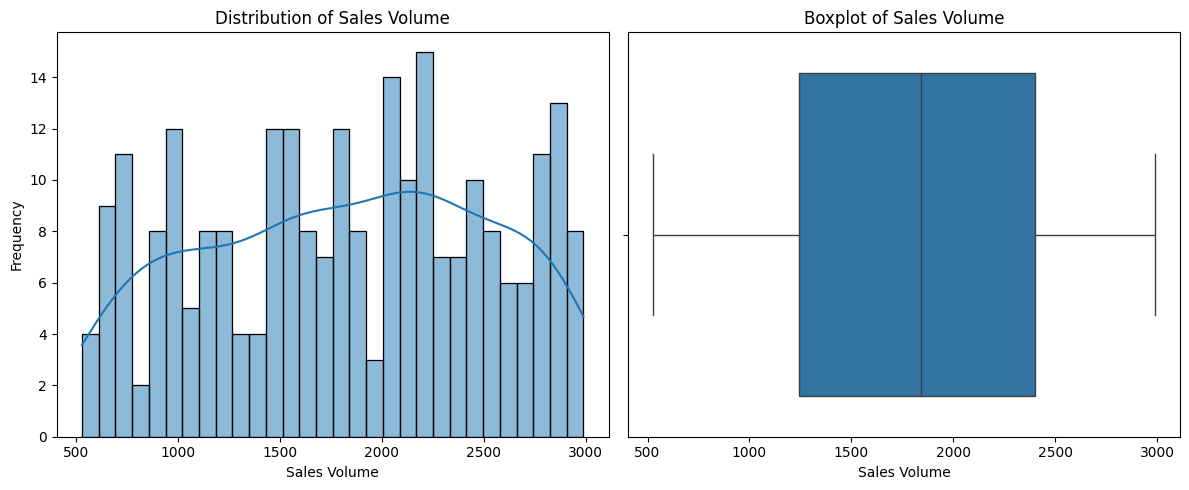

In [12]:
# Distribution and boxplot of Sales Volume in one line
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['Sales Volume'], bins=30, kde=True)
plt.title('Distribution of Sales Volume')
plt.xlabel('Sales Volume')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Sales Volume'])
plt.title('Boxplot of Sales Volume')
plt.xlabel('Sales Volume')

plt.tight_layout()
plt.show()

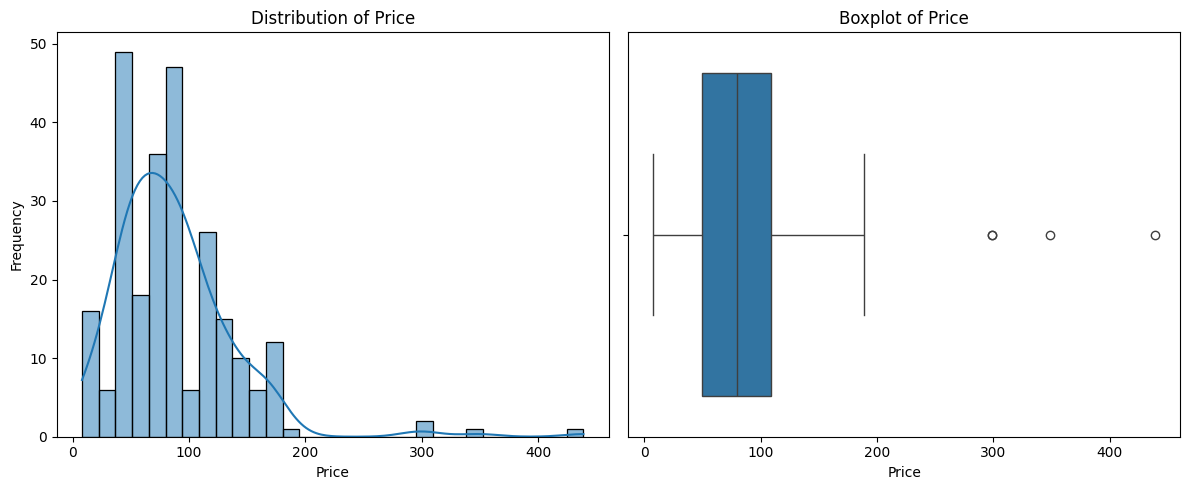

In [13]:
# Distribution and boxplot of Price in one line
plt.figure(figsize=(12, 5))
# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df['price'])
plt.title('Boxplot of Price')
plt.xlabel('Price')
plt.tight_layout()
plt.show()


In [14]:
#identify the outliers of price
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_price = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print("Number of outliers in price:", len(outliers_price))

Number of outliers in price: 4


In [15]:
outliers_price.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
13,151396,Front of Store,Yes,Clothing,Yes,729,Zara,https://www.zara.com/us/en/cropped-leather-jac...,323134418-800-3,CROPPED LEATHER JACKET,Leather jacket. Cropped length. Lapel collar a...,439.0,USD,2024-02-19T08:50:13.771115,jackets,MAN
22,161909,Aisle,Yes,Clothing,No,1290,Zara,https://www.zara.com/us/en/leather-jacket-p054...,315529534-705-3,LEATHER JACKET,Relaxed fit jacket in leather. Spread collar a...,299.0,USD,2024-02-19T08:50:18.813979,jackets,MAN
38,114877,Aisle,No,Clothing,No,1860,Zara,https://www.zara.com/us/en/suede-jacket-p02521...,323134415-700-3,SUEDE JACKET,Jacket made of suede. Cropped length. Lapel co...,349.0,USD,2024-02-19T08:50:29.497634,jackets,MAN
60,151925,End-cap,Yes,Clothing,Yes,2179,Zara,https://www.zara.com/us/en/vintage-effect-leat...,320774184-800-97,VINTAGE EFFECT LEATHER BOMBER JACKET,NaN,299.0,USD,2024-02-19T08:50:43.543555,jackets,MAN


## 3.  Explore columns with qualitative (categorical) data:


In [16]:
df.describe(include='object')

,Product Position,Promotion,Product Category,Seasonal,brand,url,sku,name,description,currency,scraped_at,terms,section
count,252,252,252,252,252,252,252,251,250,252,252,252,252
unique,3,2,1,2,1,228,228,194,221,1,229,5,2
top,Aisle,No,Clothing,Yes,Zara,https://www.zara.com/us/en/oversized-knit-swea...,318209963-800-2,PLAID OVERSHIRT,Varsity jacket with elastic collar and long sl...,USD,2024-02-19T09:10:39.415761,jackets,MAN
freq,97,132,252,128,252,2,2,6,4,252,2,140,218


/var/folders/q8/kx3w73hx1y36symw5dvy33w40000gn/T/ipykernel_52827/3046206168.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Product Position', ax=axes[0, 0], palette='viridis')
/var/folders/q8/kx3w73hx1y36symw5dvy33w40000gn/T/ipykernel_52827/3046206168.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Promotion', ax=axes[0, 1], palette='coolwarm')
/var/folders/q8/kx3w73hx1y36symw5dvy33w40000gn/T/ipykernel_52827/3046206168.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Seasonal', ax=axes[1

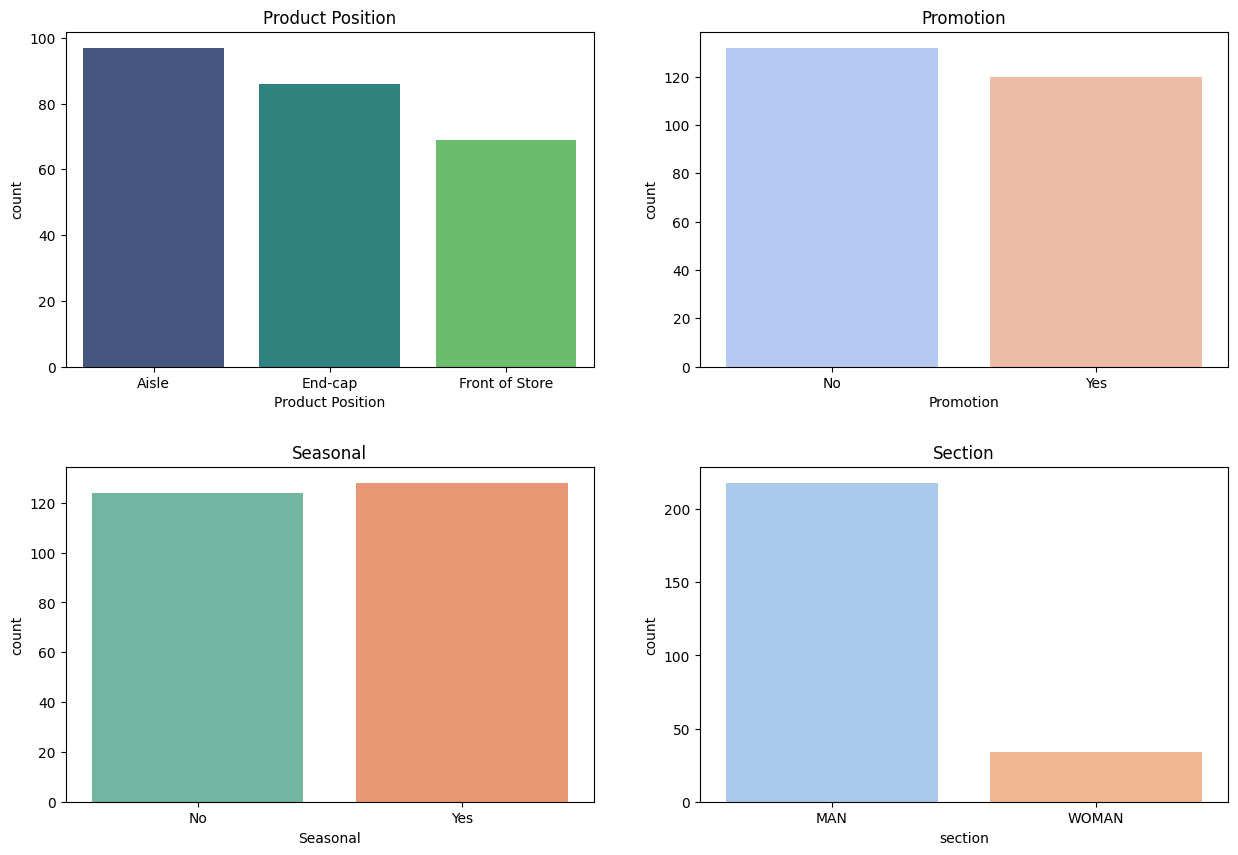

In [17]:
# Distribution of categorical variables [Product Position, Promotion, Seasonal, Section]
fig, axes = plt.subplots(2, 2, figsize=(15, 10), gridspec_kw={'hspace': 0.3, 'wspace': 0.2})

# Product Position
sns.countplot(data=df, x='Product Position', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Product Position')

# Promotion
sns.countplot(data=df, x='Promotion', ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Promotion')

# Seasonal
sns.countplot(data=df, x='Seasonal', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Seasonal')

# Section
sns.countplot(data=df, x='section', ax=axes[1, 1], palette='pastel')
axes[1, 1].set_title('Section')

plt.tight_layout()
plt.show()

/var/folders/q8/kx3w73hx1y36symw5dvy33w40000gn/T/ipykernel_52827/3793544529.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='terms', palette='Set2')


<Axes: xlabel='terms', ylabel='count'>

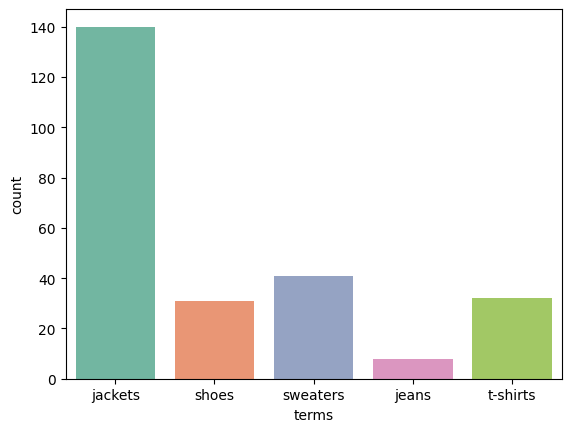

In [18]:
#terms
sns.countplot(data=df, x='terms', palette='Set2')

## Bivariate Analysis

In [19]:
#promotion vs seasonal 
import scipy.stats as stats
observed = pd.crosstab(df['Promotion'], df['Seasonal'])
chi2, p, dof, expected = stats.chi2_contingency(observed)
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: Promotion and Seasonal are dependent.")
else:
    print("Fail to reject the null hypothesis: Promotion and Seasonal are independent.")


Fail to reject the null hypothesis: Promotion and Seasonal are independent.


In [20]:
# Promotion vs  Terms
observed = pd.crosstab(df['Promotion'], df['terms'])
chi2, p, dof, expected = stats.chi2_contingency(observed)
alpha = 0.05  
if p < alpha:
    print("Reject the null hypothesis: Promotion and Terms are dependent.")
else:
    print("Fail to reject the null hypothesis: Promotion and Terms are independent.")

Fail to reject the null hypothesis: Promotion and Terms are independent.


In [21]:
#Promotion vs Section
observed = pd.crosstab(df['Promotion'], df['section'])
chi2, p, dof, expected = stats.chi2_contingency(observed)
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: Promotion and Section are dependent.")
else:
    print("Fail to reject the null hypothesis: Promotion and Section are independent.")

Fail to reject the null hypothesis: Promotion and Section are independent.


In [22]:
#promotion vs Product Position
observed = pd.crosstab(df['Promotion'], df['Product Position'])
chi2, p, dof, expected = stats.chi2_contingency(observed)           
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: Promotion and Product Position are dependent.")
else:
    print("Fail to reject the null hypothesis: Promotion and Product Position are independent.")

Fail to reject the null hypothesis: Promotion and Product Position are independent.


In [23]:
#Product Position vs Section
observed = pd.crosstab(df['Product Position'], df['section'])
chi2, p, dof, expected = stats.chi2_contingency(observed)
alpha = 0.05    
if p < alpha:
    print("Reject the null hypothesis: Product Position and Section are dependent.")
else:       
    print("Fail to reject the null hypothesis: Product Position and Section are independent.")

Fail to reject the null hypothesis: Product Position and Section are independent.


In [24]:
#product position vs terms
observed = pd.crosstab(df['Product Position'], df['terms'])
chi2, p, dof, expected = stats.chi2_contingency(observed)
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: Product Position and Terms are dependent.")
else:
    print("Fail to reject the null hypothesis: Product Position and Terms are independent.")

Fail to reject the null hypothesis: Product Position and Terms are independent.


In [25]:
#section vs terms
observed = pd.crosstab(df['section'], df['terms'])
chi2, p, dof, expected = stats.chi2_contingency(observed)
alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: Section and Terms are dependent.")
else:
    print("Fail to reject the null hypothesis: Section and Terms are independent.")


Reject the null hypothesis: Section and Terms are dependent.


In [26]:
# remove irrelevant columns
df.drop(['Product Category','brand', 'url','sku', 'description', 'currency', 'scraped_at'],axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        252 non-null    int64  
 1   Product Position  252 non-null    object 
 2   Promotion         252 non-null    object 
 3   Seasonal          252 non-null    object 
 4   Sales Volume      252 non-null    int64  
 5   name              251 non-null    object 
 6   price             252 non-null    float64
 7   terms             252 non-null    object 
 8   section           252 non-null    object 
dtypes: float64(1), int64(2), object(6)
memory usage: 17.8+ KB


In [27]:
# Create a new column called "Total"
df["Total"] = df["price"] * df["Sales Volume"]
df.head()

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,name,price,terms,section,Total
0,185102,Aisle,No,No,2823,BASIC PUFFER JACKET,19.99,jackets,MAN,56431.77
1,188771,Aisle,No,No,654,TUXEDO JACKET,169.00,jackets,MAN,110526.00
2,180176,End-cap,Yes,Yes,2220,SLIM FIT SUIT JACKET,129.00,jackets,MAN,286380.00
3,112917,Aisle,Yes,Yes,1568,STRETCH SUIT JACKET,129.00,jackets,MAN,202272.00
4,192936,End-cap,No,Yes,2942,DOUBLE FACED JACKET,139.00,jackets,MAN,408938.00


In [28]:
df.section.unique()

array(['MAN', 'WOMAN'], dtype=object)

In [29]:
#replace the values in the section column
df.loc[df['section']=='WOMAN', "section"]="Woman"
df.loc[df['section']=='MAN', "section"]="Man"

In [30]:
df.section.unique()

array(['Man', 'Woman'], dtype=object)

# Data Analysis


In [31]:
# totl sales per gender 
df.groupby('section')['Total'].sum().reset_index()

,section,Total
0,Man,35712663.03
1,Woman,3275813.45


/var/folders/q8/kx3w73hx1y36symw5dvy33w40000gn/T/ipykernel_52827/4151946586.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='section', y='Total', data=df, palette='Set2')


<Axes: xlabel='section', ylabel='Total'>

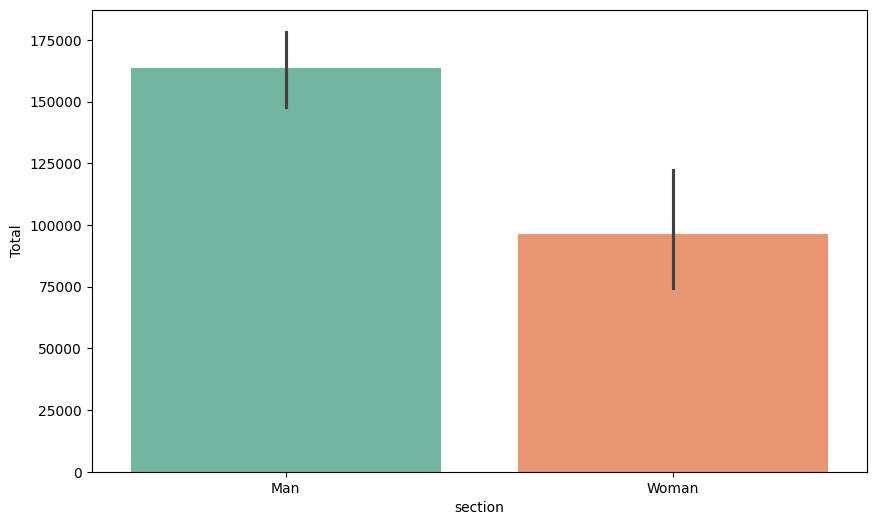

In [32]:

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='section', y='Total', data=df, palette='Set2')

In [33]:
df.groupby('Product Position')['Total'].sum().reset_index()


,Product Position,Total
0,Aisle,15481438.43
1,End-cap,12546465.81
2,Front of Store,10960572.24


/var/folders/q8/kx3w73hx1y36symw5dvy33w40000gn/T/ipykernel_52827/2504945700.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Position', y='Total', data=df, palette='Set2')


<Axes: xlabel='Product Position', ylabel='Total'>

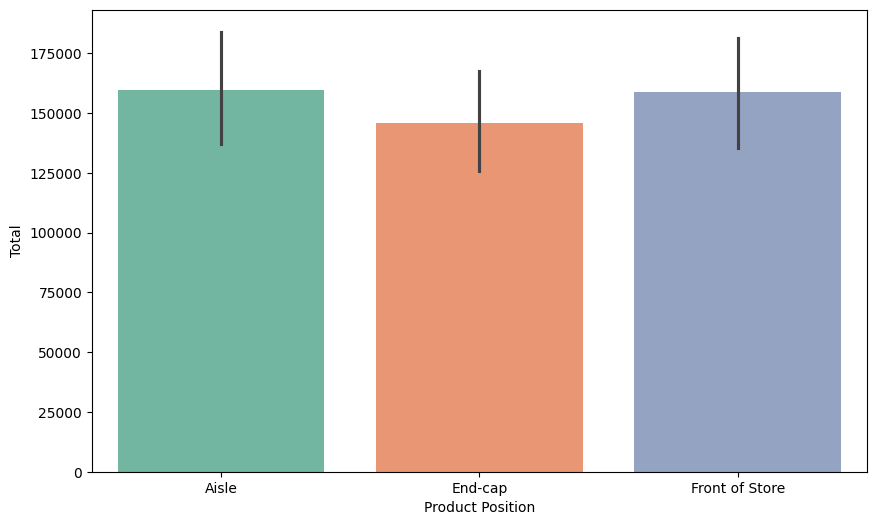

In [34]:
#total sales per items
# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Product Position', y='Total', data=df, palette='Set2')

#### Takeaway:

Product Position in Aisle have higher sales than others 

In [35]:
#Total sales per terms
df.groupby('terms')['Total'].sum().reset_index()

,terms,Total
0,jackets,26581815.87
1,jeans,864385.25
2,shoes,3754837.63
3,sweaters,4090631.48
4,t-shirts,3696806.25


/var/folders/q8/kx3w73hx1y36symw5dvy33w40000gn/T/ipykernel_52827/3310462147.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='terms', y='Total', data=df, palette='Set2')


<Axes: xlabel='terms', ylabel='Total'>

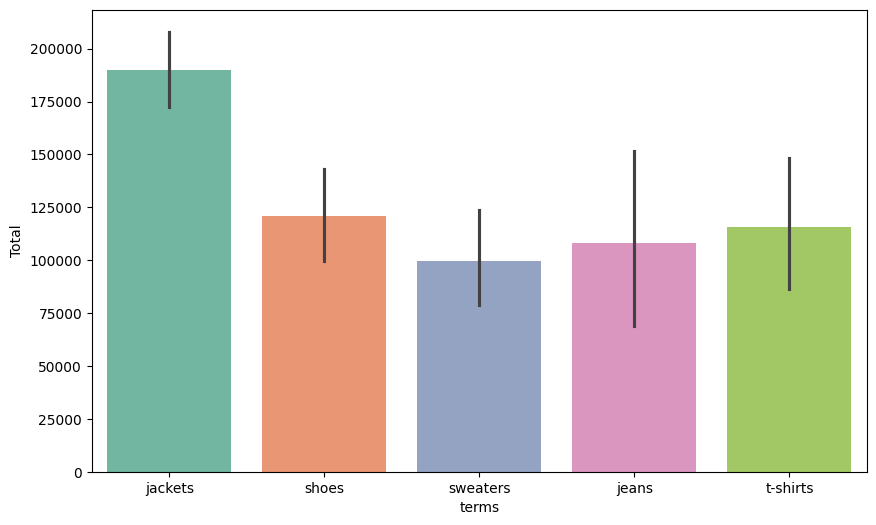

In [36]:
# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='terms', y='Total', data=df, palette='Set2')


In [37]:
#Total sales per promotion
df.groupby('Promotion')['Total'].sum().reset_index()

,Promotion,Total
0,No,18994089.58
1,Yes,19994386.90


#### Takeaway:

Seasonal products showed a slight increase in sales compared to non-seasonal ones, with a difference of approximately 3.53%.

/var/folders/q8/kx3w73hx1y36symw5dvy33w40000gn/T/ipykernel_52827/602939109.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Promotion', y='Total', data=df, palette='Set2')


<Axes: xlabel='Promotion', ylabel='Total'>

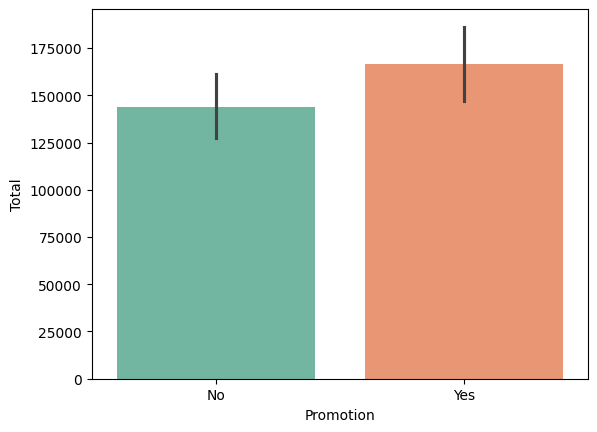

In [38]:
sns.barplot(x='Promotion', y='Total', data=df, palette='Set2')

In [39]:
#Total sales per name of the product and term 
pd.DataFrame(df.groupby(['name','terms'])['Total'].sum().sort_values(ascending=False).head(20))


,,Total
name,terms,
CONTRASTING PATCHES BOMBER JACKET,jackets,889308.00
PLAID OVERSHIRT,jackets,695369.00
RIB COLLAR JACKET,jackets,685883.00
SLIM FIT SUIT JACKET,jackets,675719.00
POCKET OVERSHIRT,jackets,666987.80
VINTAGE EFFECT LEATHER BOMBER JACKET,jackets,651521.00
SUEDE JACKET,jackets,649140.00
POCKET JACKET,jackets,608503.00
FAUX LEATHER OVERSIZED JACKET LIMITED EDITION,jackets,565209.00


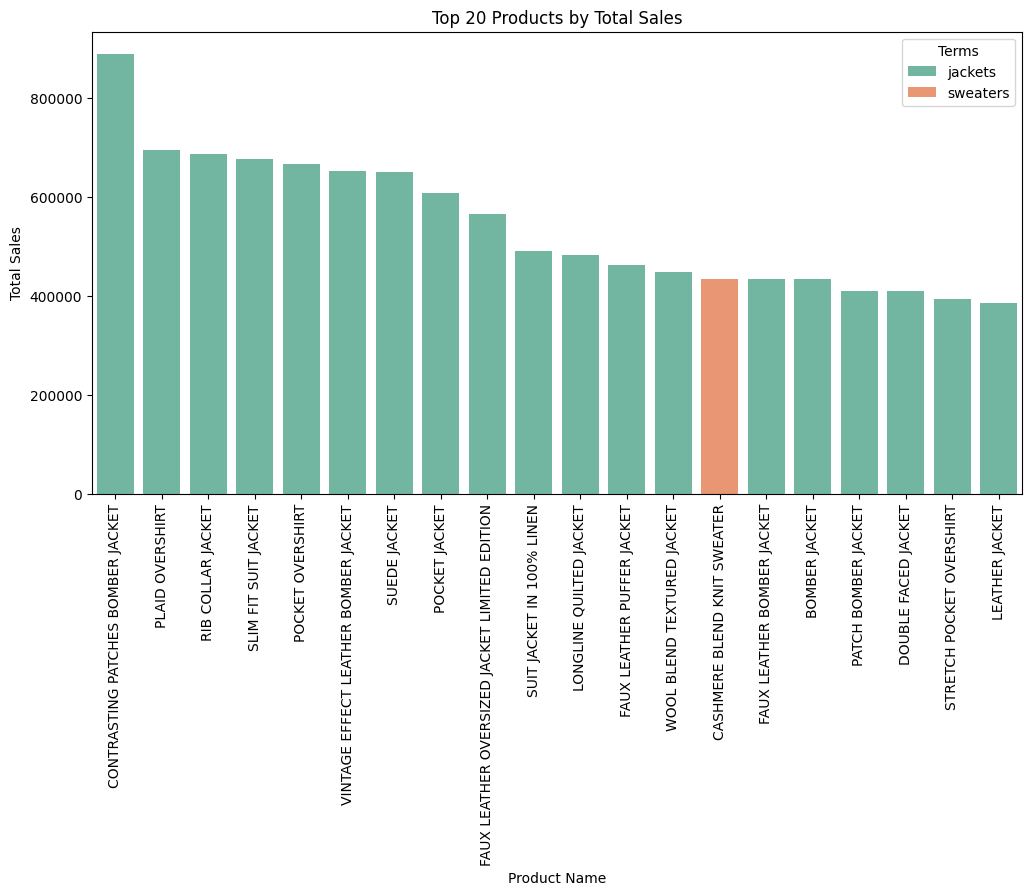

In [40]:
#Visualize the top 20 products by total sales
top_20_products = df.groupby(['name', 'terms'])['Total'].sum().reset_index()
top_20_products = top_20_products.sort_values(by='Total', ascending=False).head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x='name', y='Total', hue='terms', data=top_20_products, palette='Set2')
plt.xticks(rotation=90)
plt.title('Top 20 Products by Total Sales')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.legend(title='Terms')

#### Takeaway:

I see that jackets have the most sales 

# **Thank you for your time**